# analysis.diversity

This notebook is aimed to compute:
- Alpha-Diversity according to different metrics (species richness and Chao1)
- Statistical differences between habitats and disturbance levels
- Post hoc analysis

Additionally, this notebook also creates the inputs for a correlation analysis carried out later.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from daforfer import DaforferDB
from skbio.diversity.alpha import chao1
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌─────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│        name         │                                                                                  description                                                                                   │
│       varchar       │                                                                                    varchar                                                                                     │
├─────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits      │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the library where the detection took place, taxid, scientific name and the PAB labe

In [30]:
si = DaforferDB(conf['si'])
si.toc()

┌─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  name   │                                                        description                                                        │
│ varchar │                                                          varchar                                                          │
├─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1 │ Table S1: Library sites and context                                                                                       │
│ TableS2 │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3 │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4 │ Habitat-level diversity and number o

## PAB Diversity estimations


### Calculations

In [31]:
# metadata = db.conn.sql('SELECT * FROM D_sites').df()
# bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
# bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
# bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
# bacteria_hits

We simply create a list of item counts in one of the columns. 

In [34]:
alpha_diversity = db.conn.sql('SELECT * FROM D_Site_level_div').df()
alpha_diversity

,site,habitat,disturbed,species_richness_bact,chao1_bact,species_richness_vir,chao1_vir,species_richness_plant,chao1_plant,species_richness_host,chao1_host,total_cooccurrences
0,C1,Crop,disturbed,6,21.000000,18,27.166667,16,136.0,4,5.500000,5
1,C2,Crop,disturbed,8,18.500000,12,16.200000,22,253.0,5,8.000000,6
2,H1,Crop,disturbed,1,1.000000,13,18.600000,6,21.0,3,3.500000,0
3,H2,Crop,disturbed,1,1.000000,12,15.750000,5,15.0,3,3.500000,2
4,H3,Crop,disturbed,4,10.000000,33,58.666667,9,45.0,4,5.500000,5
5,M1,Crop,disturbed,2,2.000000,20,23.000000,14,105.0,5,11.000000,3
6,M2,Crop,disturbed,1,1.000000,13,31.333333,9,45.0,4,10.000000,1
7,M3,Crop,disturbed,2,3.000000,9,11.000000,11,66.0,4,5.500000,4
8,M4,Crop,disturbed,1,1.000000,9,23.000000,15,120.0,3,3.500000,3
9,Z1,Crop,disturbed,11,33.500000,14,21.000000,13,91.0,6,21.000000,12


### Species richness results

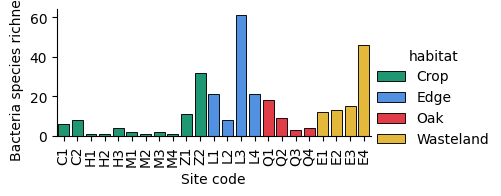

In [35]:
g = sns.catplot(alpha_diversity, x='site', y='species_richness_bact', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

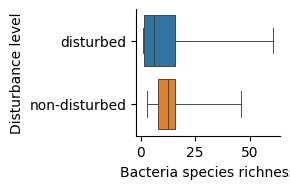

In [36]:
g = sns.catplot(
    alpha_diversity, y='disturbed', x='species_richness_bact', height=2.0, aspect=1.50, linewidth=0.65, kind='box', hue='disturbed', whis=20.0)
g.set_xlabels("Bacteria species richness")
g.set_ylabels("Disturbance level")
# g.savefig("figures/boxplot.species-richness.bydisturbance.svg")

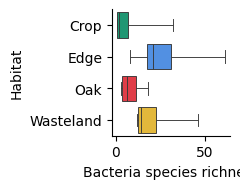

In [38]:
g = sns.catplot(
    alpha_diversity, y='habitat', x='species_richness_bact', height=2.0, aspect=1.25, 
    hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=20.0)
g.set_xlabels("Bacteria species richness")
g.set_ylabels("Habitat")
g.savefig("figures/boxplot.species-richness.byhabitat.svg")

### Chao1 diversity results 

In [39]:
alpha_diversity

,site,habitat,disturbed,species_richness_bact,chao1_bact,species_richness_vir,chao1_vir,species_richness_plant,chao1_plant,species_richness_host,chao1_host,total_cooccurrences
0,C1,Crop,disturbed,6,21.000000,18,27.166667,16,136.0,4,5.500000,5
1,C2,Crop,disturbed,8,18.500000,12,16.200000,22,253.0,5,8.000000,6
2,H1,Crop,disturbed,1,1.000000,13,18.600000,6,21.0,3,3.500000,0
3,H2,Crop,disturbed,1,1.000000,12,15.750000,5,15.0,3,3.500000,2
4,H3,Crop,disturbed,4,10.000000,33,58.666667,9,45.0,4,5.500000,5
5,M1,Crop,disturbed,2,2.000000,20,23.000000,14,105.0,5,11.000000,3
6,M2,Crop,disturbed,1,1.000000,13,31.333333,9,45.0,4,10.000000,1
7,M3,Crop,disturbed,2,3.000000,9,11.000000,11,66.0,4,5.500000,4
8,M4,Crop,disturbed,1,1.000000,9,23.000000,15,120.0,3,3.500000,3
9,Z1,Crop,disturbed,11,33.500000,14,21.000000,13,91.0,6,21.000000,12


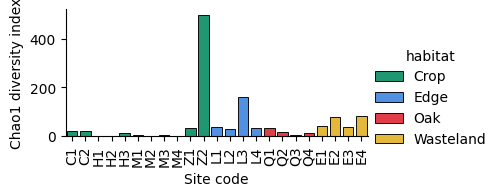

In [40]:
g = sns.catplot(alpha_diversity, x='site', y='chao1_bact', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Chao1 diversity index")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.chao1.colbyhabitat.svg")

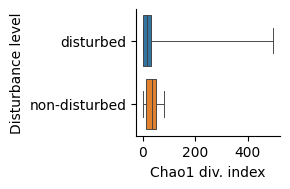

In [41]:
g = sns.catplot(
    alpha_diversity, y='disturbed', x='chao1_bact', height=2.0, aspect=1.50, linewidth=0.65, kind='box', hue='disturbed', whis=20.0)
g.set_xlabels("Chao1 div. index")
g.set_ylabels("Disturbance level")
g.savefig("figures/boxplot.chao1.bydisturbance.svg")

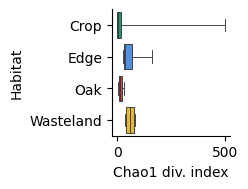

In [42]:
g = sns.catplot(
    alpha_diversity, y='habitat', x='chao1_bact', height=2.0, aspect=1.25, 
    hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=200.0)
g.set_xlabels("Chao1 div. index")
g.set_ylabels("Habitat")
g.savefig("figures/boxplot.chao1.byhabitat.svg")

### Diversity by disturbance level

In [43]:
q1_stats = []
for metric in ['species_richness_bact', 'chao1_bact']:
    kw_h, pval = stats.mannwhitneyu(
        alpha_diversity.query('habitat == "Crop" or habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland" or habitat == "Oak"')[metric].values,
    )
    significative = pval < 0.05
    q1_stats.append(
        {'metric': metric, 'U': kw_h, 'p-val': pval, 'sign': significative}
    )
q1_stats = pd.DataFrame.from_records(q1_stats)

db.save_dataframe(
    df=q1_stats, table_name="T_ADDisturbance",
    description="Mann Whitney U test on species richness and Chao1 diversity index by disturbance level"
)
q1_stats

Saved T_ADDisturbance to db.2025-10-27


,metric,U,p-val,sign
0,species_richness_bact,39.5,0.195154,False
1,chao1_bact,37.5,0.154456,False


### Diversity by habitat

In [44]:
q2_stats = []
for metric in ['species_richness_bact', 'chao1_bact']:
    kw_h, pval = stats.kruskal(
        alpha_diversity.query('habitat == "Crop"')[metric].values,
        alpha_diversity.query('habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland"')[metric].values,
        alpha_diversity.query('habitat == "Oak"')[metric].values
    )
    significative = pval < 0.05
    q2_stats.append(
        {'metric': metric, 'H': kw_h, 'p-val': pval, 'sign': significative}
    )
q2_stats = pd.DataFrame.from_records(q2_stats)

db.save_dataframe(
    df=q2_stats, table_name="T_ADhabitat",
    description="Kruskal Wallis test on species richness and Chao1 diversity index by habitat"
)
q2_stats

Saved T_ADhabitat to db.2025-10-27


,metric,H,p-val,sign
0,species_richness_bact,10.430597,0.015239,True
1,chao1_bact,11.000373,0.011724,True


### Diversity by habitat, post-hoc analysis

In [45]:
q3_stats = []
for metric in ['species_richness_bact', 'chao1_bact']:
    for h1 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
        for h2 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
            if h1 != h2:
                kw_h, pval = stats.mannwhitneyu(
                    alpha_diversity.query('habitat == "{0}"'.format(h1))[metric].values,
                    alpha_diversity.query('habitat == "{0}"'.format(h2))[metric].values,
                )
                significative = pval < 0.05
                q3_stats.append(
                    {'metric': metric, 'group_1': h1, 'group_2': h2, 'U': kw_h, 'p-val': pval, 'sign': significative}
                )
q3_stats_df = pd.DataFrame.from_records(q3_stats)

db.save_dataframe(
    df=q3_stats_df, table_name="T_ADHabitatPH",
    description="Post-Hoc Mann Whitney U analysis on species richness and Chao1 diversity index by habitat"
)
si.save_dataframe(
    df=q3_stats_df, table_name="TableS5",
    description="Mann-Whitney U post-hoc test on site-diversity by habitat"
)
q3_stats_df

Saved T_ADHabitatPH to db.2025-10-27
Saved TableS5 to si.2025-10-27


,metric,group_1,group_2,U,p-val,sign
0,species_richness_bact,Crop,Edge,4.5,0.024723,True
1,species_richness_bact,Crop,Wasteland,3.0,0.014711,True
2,species_richness_bact,Crop,Oak,12.5,0.234904,False
3,species_richness_bact,Edge,Crop,39.5,0.024723,True
4,species_richness_bact,Edge,Wasteland,10.0,0.663117,False
5,species_richness_bact,Edge,Oak,14.0,0.110210,False
6,species_richness_bact,Wasteland,Crop,41.0,0.014711,True
7,species_richness_bact,Wasteland,Edge,6.0,0.663117,False
8,species_richness_bact,Wasteland,Oak,13.0,0.200000,False
9,species_richness_bact,Oak,Crop,31.5,0.234904,False


In [46]:
q3_stats_df.query('metric == "species_richness_bact"')

,metric,group_1,group_2,U,p-val,sign
0,species_richness_bact,Crop,Edge,4.5,0.024723,True
1,species_richness_bact,Crop,Wasteland,3.0,0.014711,True
2,species_richness_bact,Crop,Oak,12.5,0.234904,False
3,species_richness_bact,Edge,Crop,39.5,0.024723,True
4,species_richness_bact,Edge,Wasteland,10.0,0.663117,False
5,species_richness_bact,Edge,Oak,14.0,0.110210,False
6,species_richness_bact,Wasteland,Crop,41.0,0.014711,True
7,species_richness_bact,Wasteland,Edge,6.0,0.663117,False
8,species_richness_bact,Wasteland,Oak,13.0,0.200000,False
9,species_richness_bact,Oak,Crop,31.5,0.234904,False


In [47]:
q3_stats_df.query('metric == "species_richness_bact"').pivot(index='group_1', columns='group_2', values='p-val')

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,0.024723,0.234904,0.014711
Edge,0.024723,NaN,0.110210,0.663117
Oak,0.234904,0.110210,NaN,0.200000
Wasteland,0.014711,0.663117,0.200000,NaN


In [48]:
q3_stats_df.query('metric == "species_richness_bact"').pivot(index='group_1', columns='group_2', values='U')

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,4.5,12.5,3.0
Edge,39.5,NaN,14.0,10.0
Oak,31.5,2.0,NaN,3.0
Wasteland,41.0,6.0,13.0,NaN


In [1]:
db.conn.close()
si.conn.close()

NameError: name 'db' is not defined